In [97]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [99]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV


from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style(style='whitegrid') #backgrounds style of graphs

In [101]:
# Step 2: Loading and Cleaning the Data
data = fetch_ucirepo(id=9)
data
x=data.data.features.copy() # returns allnumerical features
y=data.data.targets['mpg']

In [102]:
x.describe()
x.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [103]:
x['origin'].unique()


array([1, 3, 2])

In [104]:
x['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [105]:
# tarnsform the horesepower cml& ogrigin cml
x['horsepower']=pd.to_numeric(x['horsepower'],errors='coerce')
x['horsepower'].info()
x['origin'] = x['origin'].astype(str)

<class 'pandas.Series'>
RangeIndex: 398 entries, 0 to 397
Series name: horsepower
Non-Null Count  Dtype  
--------------  -----  
392 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


In [106]:
# X.info()

# All numerical columns into a single collection
numerical_features = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year'
]

# Categorical column
categorical_features = ['origin']

# Select only the required columns
x = x[numerical_features + categorical_features]

# Display information about the DataFrame
x.info()
x.shape

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 22.3 KB


(398, 7)

In [107]:
# quick explotary analysis
df = x.copy()
df['mpg'] = y
df

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1,27.0
394,4,97.0,52.0,2130,24.6,82,2,44.0
395,4,135.0,84.0,2295,11.6,82,1,32.0
396,4,120.0,79.0,2625,18.6,82,1,28.0


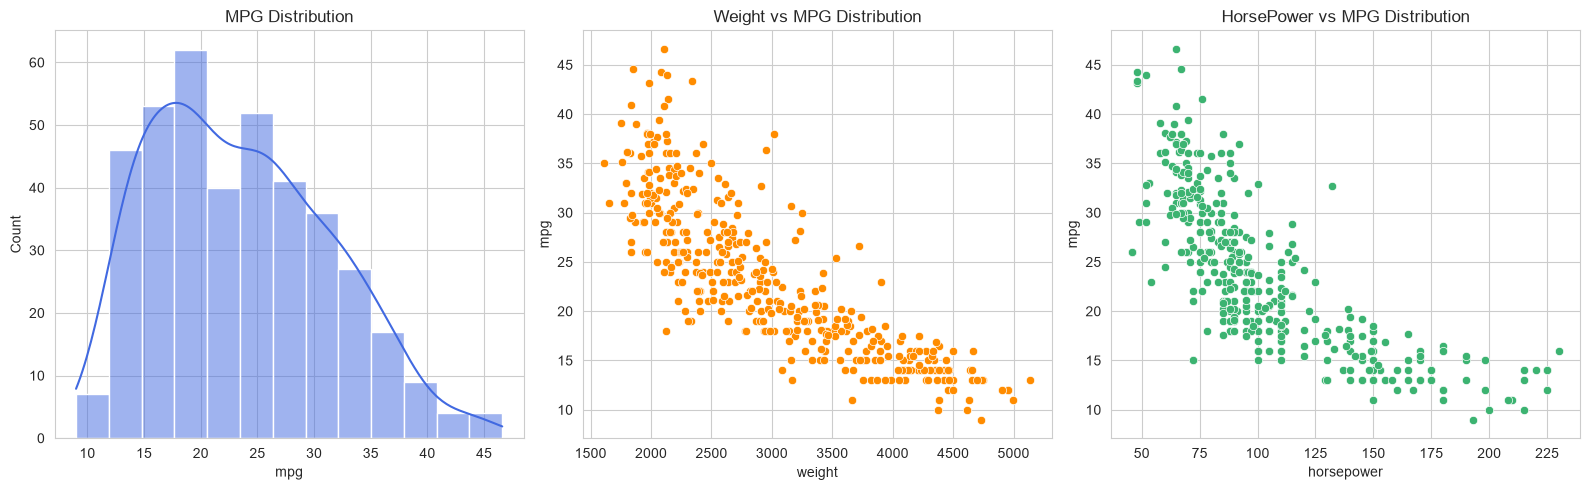

In [108]:
#step -3  Plot using seaborn's subplot() concept to divide the plot into multiple plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Plot graphs as per axes
sns.histplot(df['mpg'], kde=True, ax=axes[0], color='royalblue')
# Similar way we display other graphs in same plot
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'], y=df['mpg'], ax=axes[1], color='darkorange')
axes[1].set_title("Weight vs MPG Distribution")
sns.scatterplot(x=df['horsepower'], y=df['mpg'], ax=axes[2], color='mediumseagreen')
axes[2].set_title("HorsePower vs MPG Distribution")
plt.tight_layout()
plt.show()

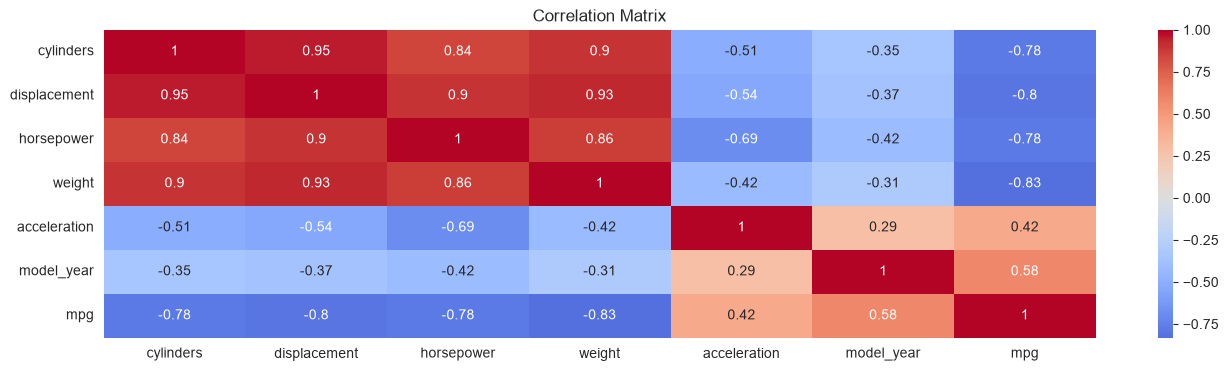

In [109]:
# Correlation between our variables

plt.figure(figsize=(16,4))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title("Correlation Matrix")
plt.show()

In [110]:
# step 4 is dividing the data into train test split
#print(x)
#print(y)
#Split rule -->70-30,80-20,75-25
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print('\n train test split')
print("Training Data",len(x_train))
print("Testing Data",len(x_test))
#print(x_train)


 train test split
Training Data 318
Testing Data 80


In [111]:
# step-5 creating the base lim model

def evaluate(model_name,actual,predicted):
    """Returns MEA,MSE,RMSE,R2-Score"""
    mse = mean_squared_error(actual,predicted)
    mae = mean_absolute_error(actual,predicted)
    return{'Model_name':model_name,
    'MAE':mean_absolute_error,
    'MSE':mse,
    'RMSE':np.sqrt(mse),
    'R2-Score':r2_score(actual,predicted)}
results=[]

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [113]:
#Step-6 : Baseline model --> It prediicts the training set for every value
baseline_predictions = np.full(len(y_test),y_train.mean())
#baseline_predictions
#in above case we are keeping a baseline prediction'
results.append(evaluate("Mean baseline",y_test,baseline_predictions))
results

[{'Model_name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686}]

In [114]:
#Step-7 : we apply Linear Regression
simple_model = LinearRegression()
#we fit the data model
simple_model.fit(x_train[['weight']],y_train)
simple_model_predictions = simple_model.predict(x_test[['weight']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:weight",y_test,simple_model_predictions))
print(len(results))


2


In [115]:
#check the intercept value
# Check the intercept value

print("Simple Linear Regression Equation")

print(f"Predicted MPG = {simple_model.intercept_} + ({simple_model.coef_[0]}) * weight")

Simple Linear Regression Equation
Predicted MPG = 46.78206336645047 + (-0.007805242351594879) * weight


In [116]:
simple_model.fit(x_train[['cylinders']],y_train)
simple_model_predictions_cylinders = simple_model.predict(x_test[['cylinders']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:cylinders",y_test,simple_model_predictions_cylinders))
print(len(results))
results

3


[{'Model_name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_name': 'Simple Linear Regression:weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_name': 'Simple Linear Regression:cylinders',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287}]

In [117]:
simple_model.fit(x_train[['displacement']],y_train)
simple_model_predictions_dip= simple_model.predict(x_test[['displacement']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:displacement",y_test,simple_model_predictions_dip))
print(len(results))
results

4


[{'Model_name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_name': 'Simple Linear Regression:weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_name': 'Simple Linear Regression:cylinders',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_name': 'Simple Linear Regression:displacement',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true

In [120]:
#step-8 multiple linear regression
preprocessor = ColumnTransformer(transformers=[("numbers",SimpleImputer(strategy="median"),numerical_features),("category",Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),
                                                                                                                                            ("encoding",OneHotEncoder(handle_unknown="ignore",drop="first"),
                                                                                                                                             )]),
                                                                                                                  categorical_features),
                                                
                                                ]
                                  
                                   )

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [121]:
multiple_model = Pipeline(
    steps =[("prepare",preprocessor),("model",LinearRegression())]
)
multiple_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['cylinders','displacement','horsepower',...,'acceleration','model_year', 'origin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [122]:
multiple_predictions = multiple_model.predict(x_test)
results.append(evaluate("Multiple Regression",y_test,multiple_predictions))
results

[{'Model_name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_name': 'Simple Linear Regression:weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_name': 'Simple Linear Regression:cylinders',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_name': 'Simple Linear Regression:displacement',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true

In [123]:
# step-9 poly regg
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

polynomial_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])
polynomial_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto a

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

polynomial_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

degree_search = GridSearchCV(
    polynomial_model,
    param_grid={"polynomial__degree": [1, 2, 3, 4, 5]},
    scoring="neg_mean_squared_error",
    cv=5
)

degree_search.fit(x_train[["horsepower"]], y_train)

polynomial_predictions = degree_search.predict(x_test[["horsepower"]])

results.append(
    evaluate("Polynomial (Horse Power)", y_test, polynomial_predictions)
)

results

[{'Model_name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_name': 'Simple Linear Regression:weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_name': 'Simple Linear Regression:cylinders',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_name': 'Simple Linear Regression:displacement',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true

In [125]:
# Best polynomial degree

best_degree =   degree_search.best_params_["polynomial__degree"]
cv_rmse = np.sqrt(-degree_search.best_score_)
print(best_degree)
print(cv_rmse)

2
4.620314169891041


In [126]:
# printthe result finally 
results= pd.DataFrame(results).sort_values("RMSE")
results

,Model_name,MAE,MSE,RMSE,R2-Score
4,Multiple Regression,<function mean_absolute_error at 0x0000026F090...,8.338668,2.887675,0.844909
5,Polynomial (Horse Power),<function mean_absolute_error at 0x0000026F090...,13.978713,3.738812,0.740010
1,Simple Linear Regression:weight,<function mean_absolute_error at 0x0000026F090...,14.894861,3.859386,0.722971
3,Simple Linear Regression:displacement,<function mean_absolute_error at 0x0000026F090...,18.102544,4.254708,0.663311
2,Simple Linear Regression:cylinders,<function mean_absolute_error at 0x0000026F090...,19.664864,4.434508,0.634254
0,Mean baseline,<function mean_absolute_error at 0x0000026F090...,53.983298,7.347333,-0.004033
